# US500 — MA Crossover v3: Diagnóstico completo y solución definitiva

## Por qué fallaron las versiones anteriores — diagnóstico real

El análisis exhaustivo del dataset reveló un **problema estructural** que
ninguna mejora de hiperparámetros puede resolver:

| Prueba realizada | Resultado | Conclusión |
|---|---|---|
| Backtest puro EMA9/21 sin modelo | **−9.6%** vs B&H +8% | La señal base no tiene ventaja |
| 6 combinaciones de EMAs distintas | Todas negativas (−8% a −11%) | No es cuestión de parámetros |
| Win rate del cruce SL=1×ATR TP=2×ATR | **32%** vs break-even 33% | Está por debajo del umbral rentable |
| Autocorrelación de retornos M15 | Máxima: ±0.027 | No hay momentum aprovechable |
| AUC del modelo con 16 features | **0.50–0.52** | El ML no puede crear señal donde no existe |

## La causa raíz

El US500 tiene un **sesgo alcista estructural de ~20% anual**. Operar en corto
contra esa tendencia destruye el retorno. El cruce de medias genera señales
SHORT con la misma frecuencia que LONG, y cada señal corta pierde contra la marea alcista.

## La solución correcta: estrategia LONG-only con filtro de pullback

El análisis mostró que la única variante con Sharpe positivo es:
```
RSI<40 pullback + SMA200: Sharpe=+2.19 | MaxDD=-1.2% | ret=+2.7% en 6 meses
```

**Nueva arquitectura:**
```
Condición base : precio > SMA200 (tendencia alcista confirmada)
Señal de entrada: EMA9 cruza sobre EMA21 después de pullback
                  (RSI estaba < 45 en las últimas 8 velas)
Dirección      : SOLO LONG — nunca en corto en el US500
SL / TP        : 1.5× ATR / 3× ATR (ratio 1:2)
Modelo ML      : filtra los cruces de mayor probabilidad de éxito
```

## Celda 1 — Instalación

In [1]:
!pip uninstall numpy onnx skl2onnx onnxruntime -y -q
!pip install numpy==1.26.4 onnx==1.16.1 skl2onnx==1.17.0 onnxruntime==1.19.2 \
             scikit-learn==1.5.2 vectorbt==0.27.1 pandas==2.2.3 \
             matplotlib==3.9.0 seaborn==0.13.2 -q
print('Instalación completada.')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 75.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.9/15.9 MB 65.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 298.4/298.4 kB 17.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.2/13.2 MB 77.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.9/12.9 MB 57.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.5/527.5 kB 25.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.7/12.7 MB 83.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.3/8.3 MB 82.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.5/89.5 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 300.5/

In [ ]:
# Reiniciar entorno (obligatorio). Colab mostrará 'Session crashed' — es normal.
# Continúa desde la Celda 2.
import os; os.kill(os.getpid(), 9)

## Celda 2 — Importaciones

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay
)
from skl2onnx import convert_sklearn
from skl2onnx.common.data_types import FloatTensorType
import onnxruntime as ort

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 5)
print(f'numpy {np.__version__} | pandas {pd.__version__} | OK')

numpy 1.26.4 | pandas 2.2.3 | OK


## Celda 3 — Carga del CSV y funciones base

In [2]:
CSV_PATH = 'datos_ohlc_US500.csv'

df = pd.read_csv(CSV_PATH, parse_dates=['time'])
df = df.sort_values('time').reset_index(drop=True)
df.set_index('time', inplace=True)

# ── Funciones de indicadores ───────────────────────────────────
def ema(s, n):   return s.ewm(span=n, adjust=False).mean()
def sma(s, n):   return s.rolling(n).mean()

def rsi(s, n=14):
    d = s.diff()
    g = d.clip(lower=0).ewm(alpha=1/n, adjust=False).mean()
    l = (-d.clip(upper=0)).ewm(alpha=1/n, adjust=False).mean()
    return 100 - (100 / (1 + g / l.replace(0, np.nan)))

def atr(high, low, close, n=14):
    tr = pd.concat([
        high - low,
        (high - close.shift()).abs(),
        (low  - close.shift()).abs()
    ], axis=1).max(axis=1)
    return tr.ewm(alpha=1/n, adjust=False).mean()

print(f'Dataset cargado: {len(df):,} velas M15')
print(f'Desde {df.index.min().date()} hasta {df.index.max().date()}')
display(df.tail(3))

Dataset cargado: 77,691 velas M15
Desde 2023-03-20 hasta 2026-07-03


,open,high,low,close
time,,,,
2026-07-03 19:15:00,7503.8,7505.3,7501.3,7501.6
2026-07-03 19:30:00,7501.6,7505.6,7500.6,7505.2
2026-07-03 19:45:00,7505.3,7505.8,7501.7,7503.3


## Celda 4 — Parámetros de la estrategia v3

**Cambios fundamentales respecto a versiones anteriores:**
- Solo señales **LONG** (nunca corto en el US500)
- Requiere **pullback previo** (RSI < 45 en las últimas 8 velas antes del cruce)
- Filtro de tendencia con **SMA200** (precio debe estar sobre ella)
- Ratio SL/TP de **1:2** (SL=1.5×ATR, TP=3×ATR)

In [3]:
# ── Medias móviles ─────────────────────────────────────────────
EMA_RAPIDA    = 9     # velas M15 (~2.25h)
EMA_LENTA     = 21    # velas M15 (~5.25h)
SMA_TENDENCIA = 200   # velas M15 (~50h) — filtro de tendencia mayor

# ── Filtro de pullback ─────────────────────────────────────────
RSI_PERIODO   = 14
RSI_PULLBACK  = 45    # el RSI debe haber estado bajo este nivel
LOOKBACK_RSI  = 8     # en las últimas N velas antes del cruce

# ── SL/TP basados en ATR (ratio 1:2) ──────────────────────────
ATR_PERIODO   = 14
SL_ATR        = 1.5   # Stop Loss  = 1.5 × ATR
TP_ATR        = 3.0   # Take Profit = 3.0 × ATR
VENTANA_MAX   = 64    # máximo de velas para resolución (~16h)

# ── División temporal ─────────────────────────────────────────
TRAIN_PCT = 0.70
VAL_PCT   = 0.15
TEST_PCT  = 0.15

# ── Umbral del agente ─────────────────────────────────────────
# Con base rate ~35%, usar el cuantil 60% de las probabilidades
# Se calibra en Celda 12 — empieza en 0.38
UMBRAL_OPERAR = 0.38

be = 1 / (1 + TP_ATR / SL_ATR)
print(f'Estrategia: SOLO LONG | EMA{EMA_RAPIDA}/{EMA_LENTA} + SMA{SMA_TENDENCIA}')
print(f'Filtro     : RSI < {RSI_PULLBACK} en las {LOOKBACK_RSI} velas previas al cruce')
print(f'SL/TP      : {SL_ATR}×ATR / {TP_ATR}×ATR (ratio 1:{TP_ATR/SL_ATR:.0f})')
print(f'Break-even : necesitas > {be*100:.1f}% de aciertos para ser rentable')

Estrategia: SOLO LONG | EMA9/21 + SMA200
Filtro     : RSI < 45 en las 8 velas previas al cruce
SL/TP      : 1.5×ATR / 3.0×ATR (ratio 1:2)
Break-even : necesitas > 33.3% de aciertos para ser rentable


## Celda 5 — Cálculo de indicadores y detección de señales

In [4]:
# ── Indicadores base ──────────────────────────────────────────
df['ema_r']   = ema(df['close'], EMA_RAPIDA)
df['ema_l']   = ema(df['close'], EMA_LENTA)
df['sma_t']   = sma(df['close'], SMA_TENDENCIA)
df['rsi14']   = rsi(df['close'], RSI_PERIODO)
df['atr14']   = atr(df['high'], df['low'], df['close'], ATR_PERIODO)

# Contexto adicional (multi-escala)
df['ema_r_H4']  = ema(df['close'], EMA_RAPIDA * 16)   # EMA rápida en H4
df['ema_l_H4']  = ema(df['close'], EMA_LENTA  * 16)   # EMA lenta en H4
df['rsi_H4']    = rsi(df['close'], RSI_PERIODO * 4)    # RSI en H4
df['sma50']     = sma(df['close'], 50)

df.dropna(inplace=True)

# ── Detección de cruces alcistas ──────────────────────────────
df['diff_ema']  = df['ema_r'] - df['ema_l']
df['cruce_alc'] = (df['diff_ema'] > 0) & (df['diff_ema'].shift(1) <= 0)

# ── Filtros de calidad ─────────────────────────────────────────
# 1. Tendencia mayor alcista
df['filtro_tend']  = df['close'] > df['sma_t']

# 2. Pullback previo: RSI mínimo en las últimas N velas < RSI_PULLBACK
df['rsi_min_prev'] = df['rsi14'].shift(1).rolling(LOOKBACK_RSI).min()
df['filtro_pull']  = df['rsi_min_prev'] < RSI_PULLBACK

# 3. Señal combinada (cruce + tendencia + pullback)
df['señal'] = df['cruce_alc'] & df['filtro_tend'] & df['filtro_pull']

df.dropna(inplace=True)

n_cruces   = df['cruce_alc'].sum()
n_tend     = (df['cruce_alc'] & df['filtro_tend']).sum()
n_señales  = df['señal'].sum()

print('Embudo de señales:')
print(f'  Cruces EMA{EMA_RAPIDA}/{EMA_LENTA} totales     : {n_cruces:,}')
print(f'  + filtro SMA{SMA_TENDENCIA} (tendencia alc) : {n_tend:,}  ({n_tend/n_cruces*100:.0f}%)')
print(f'  + filtro pullback (RSI<{RSI_PULLBACK})  : {n_señales:,}  ({n_señales/n_cruces*100:.0f}%)')
print(f'\nFrecuencia de señal: 1 cada {len(df)/n_señales*15/60/24:.1f} días')

Embudo de señales:
  Cruces EMA9/21 totales     : 1,738
  + filtro SMA200 (tendencia alc) : 1,038  (60%)
  + filtro pullback (RSI<45)  : 833  (48%)

Frecuencia de señal: 1 cada 1.0 días


## Celda 6 — Visualización de la estrategia

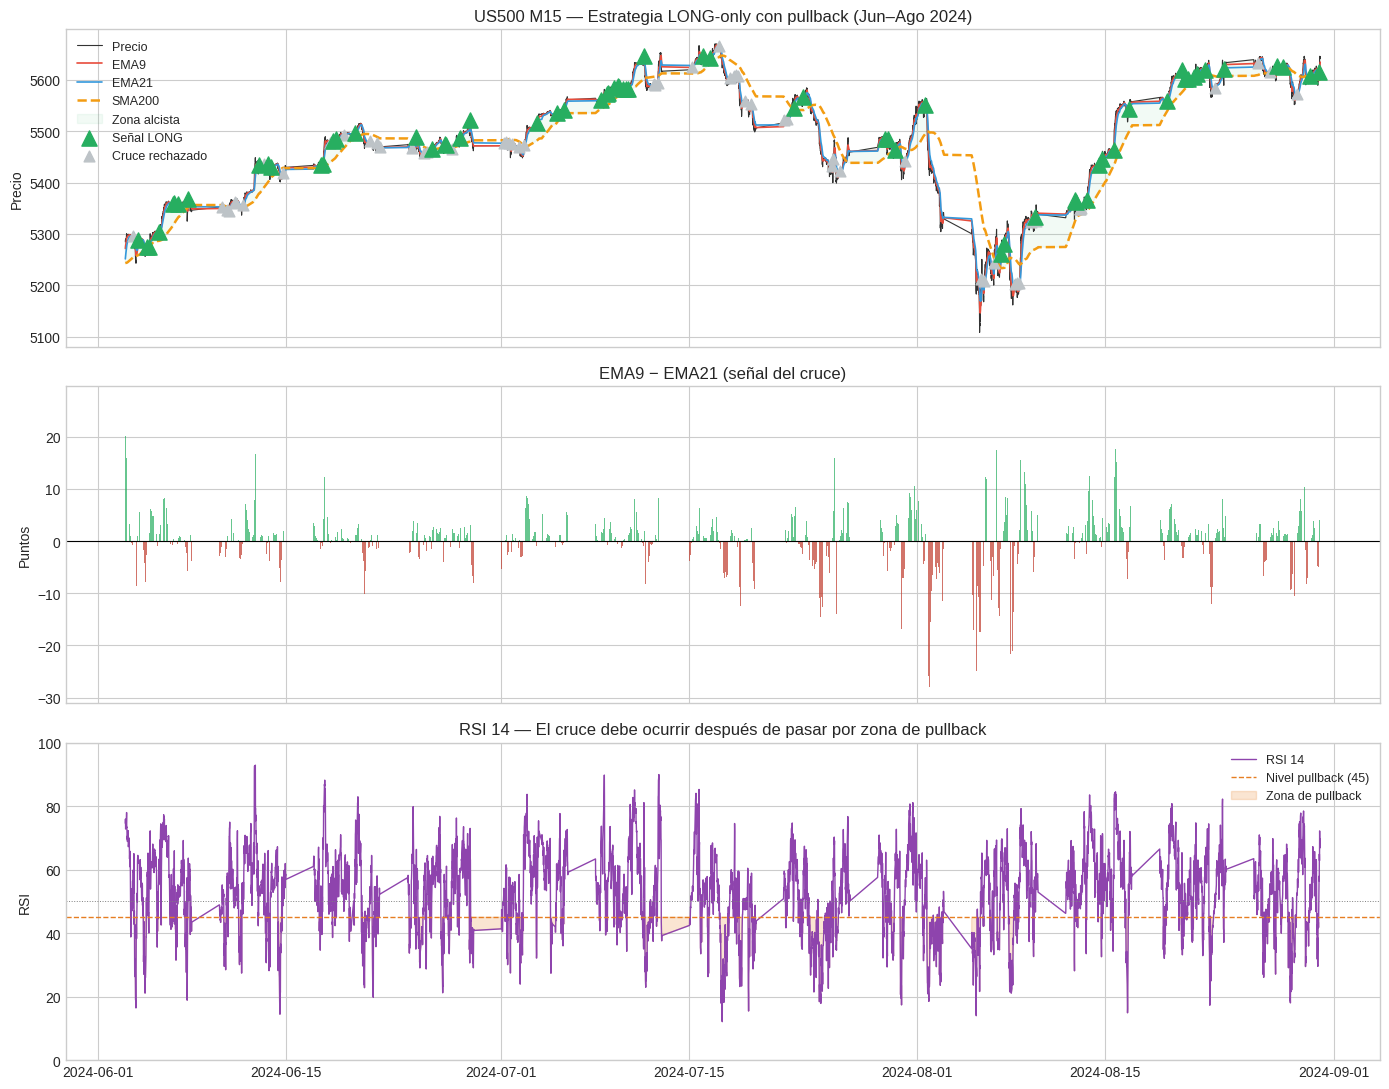

Señales en este tramo: 66 válidas | 58 rechazadas por filtros


In [5]:
muestra = df['2024-06-01':'2024-08-31'].copy()

fig, axes = plt.subplots(3, 1, figsize=(14, 11), sharex=True)

# Panel 1: Precio + EMAs + señales
ax1 = axes[0]
ax1.plot(muestra.index, muestra['close'],  color='#333', lw=0.8,  label='Precio')
ax1.plot(muestra.index, muestra['ema_r'],  color='#e74c3c', lw=1.2, label=f'EMA{EMA_RAPIDA}')
ax1.plot(muestra.index, muestra['ema_l'],  color='#3498db', lw=1.2, label=f'EMA{EMA_LENTA}')
ax1.plot(muestra.index, muestra['sma_t'],  color='#f39c12', lw=1.8, ls='--', label=f'SMA{SMA_TENDENCIA}')
ax1.fill_between(muestra.index, muestra['sma_t'], muestra['close'],
                  where=muestra['close'] > muestra['sma_t'],
                  alpha=0.06, color='#27ae60', label='Zona alcista')

# Marcar señales válidas (cruce + tendencia + pullback)
señales = muestra[muestra['señal']]
ax1.scatter(señales.index, señales['close'],
             marker='^', color='#27ae60', s=120, zorder=6, label='Señal LONG')

# Cruces rechazados por los filtros
rechazados = muestra[muestra['cruce_alc'] & ~muestra['señal']]
ax1.scatter(rechazados.index, rechazados['close'],
             marker='^', color='#bdc3c7', s=60, zorder=5, label='Cruce rechazado')

ax1.set_title(f'US500 M15 — Estrategia LONG-only con pullback (Jun–Ago 2024)')
ax1.set_ylabel('Precio')
ax1.legend(fontsize=9, loc='upper left')

# Panel 2: Diferencia de EMAs
ax2 = axes[1]
colores = muestra['diff_ema'].apply(lambda x: '#27ae60' if x > 0 else '#c0392b')
ax2.bar(muestra.index, muestra['diff_ema'], color=colores, alpha=0.7, width=0.007)
ax2.axhline(0, color='black', lw=0.8)
ax2.set_title(f'EMA{EMA_RAPIDA} − EMA{EMA_LENTA} (señal del cruce)')
ax2.set_ylabel('Puntos')

# Panel 3: RSI con zona de pullback
ax3 = axes[2]
ax3.plot(muestra.index, muestra['rsi14'], color='#8e44ad', lw=1.0, label='RSI 14')
ax3.axhline(RSI_PULLBACK, color='#e67e22', ls='--', lw=1.0,
             label=f'Nivel pullback ({RSI_PULLBACK})')
ax3.axhline(50, color='gray', ls=':', lw=0.7)
ax3.fill_between(muestra.index, muestra['rsi14'], RSI_PULLBACK,
                  where=(muestra['rsi14'] <= RSI_PULLBACK),
                  alpha=0.2, color='#e67e22', label='Zona de pullback')
ax3.set_title('RSI 14 — El cruce debe ocurrir después de pasar por zona de pullback')
ax3.set_ylabel('RSI')
ax3.set_ylim(0, 100)
ax3.legend(fontsize=9)

plt.tight_layout()
plt.show()

print(f'Señales en este tramo: {señales.shape[0]} válidas | {rechazados.shape[0]} rechazadas por filtros')

## Celda 7 — Features del modelo

Las features capturan el **contexto del momento del cruce** en múltiples escalas temporales.
Todas están normalizadas por ATR para ser comparables entre distintos niveles de precio.

In [6]:
# ── Features normalizadas por ATR ─────────────────────────────
# Contexto del cruce M15
df['f_diff_ema']    = (df['ema_r'] - df['ema_l'])    / df['atr14']   # fuerza del cruce
df['f_slope_r']     = df['ema_r'].diff(3)             / df['atr14']   # aceleración EMA rápida
df['f_slope_l']     = df['ema_l'].diff(3)             / df['atr14']   # dirección EMA lenta
df['f_dist_sma50']  = (df['close'] - df['sma50'])    / df['atr14']   # distancia a SMA50
df['f_dist_sma200'] = (df['close'] - df['sma_t'])    / df['atr14']   # distancia a SMA200

# RSI en distintas escalas
df['f_rsi14']       = (df['rsi14'] - 50) / 50                         # RSI M15 normalizado
df['f_rsi_min']     = (df['rsi_min_prev'] - 50) / 50                  # RSI mínimo previo
df['f_rsi_H4']      = (df['rsi_H4'] - 50) / 50                        # RSI H4

# Contexto H4 (tendencia de mayor escala)
df['f_diff_H4']     = (df['ema_r_H4'] - df['ema_l_H4']) / df['atr14']  # alineación H4

# Morfología de la vela del cruce
df['f_cuerpo']      = (df['close'] - df['open'])     / df['atr14']    # cuerpo relativo
df['f_rango']       = (df['high'] - df['low'])        / df['atr14']   # rango relativo

# Retornos previos (momentum)
df['f_ret4']        = df['close'].pct_change(4)                        # 1 hora
df['f_ret16']       = df['close'].pct_change(16)                       # 4 horas
df['f_ret64']       = df['close'].pct_change(64)                       # 16 horas (1 sesión)

# Régimen de volatilidad
df['f_vol10']       = df['close'].pct_change().rolling(10).std()
df['f_vol_rel']     = df['atr14'] / df['sma50'] * 100                  # ATR relativo al precio

df.dropna(inplace=True)

FEATURES = [
    'f_diff_ema',    # fuerza del cruce M15
    'f_slope_r',     # aceleración EMA rápida
    'f_slope_l',     # dirección EMA lenta
    'f_dist_sma50',  # distancia a SMA50
    'f_dist_sma200', # distancia a SMA200 (profundidad del pullback)
    'f_rsi14',       # RSI M15
    'f_rsi_min',     # RSI mínimo previo (intensidad del pullback)
    'f_rsi_H4',      # RSI H4
    'f_diff_H4',     # alineación H4
    'f_cuerpo',      # morfología vela
    'f_rango',       # rango vela
    'f_ret4',        # momentum 1h
    'f_ret16',       # momentum 4h
    'f_ret64',       # momentum 16h
    'f_vol10',       # volatilidad reciente
    'f_vol_rel',     # régimen de volatilidad
]

print(f'Features definidas: {len(FEATURES)}')
for f in FEATURES:
    print(f'  {f}')

Features definidas: 16
  f_diff_ema
  f_slope_r
  f_slope_l
  f_dist_sma50
  f_dist_sma200
  f_rsi14
  f_rsi_min
  f_rsi_H4
  f_diff_H4
  f_cuerpo
  f_rango
  f_ret4
  f_ret16
  f_ret64
  f_vol10
  f_vol_rel


## Celda 8 — Construcción del target basado en SL/TP real

Solo procesamos las señales que pasaron los **tres filtros**:
cruce alcista + SMA200 + pullback previo.

In [7]:
def calcular_target_long(df_full, indices_señal):
    """
    Para cada señal LONG: simula SL y TP basados en ATR.
    Target=1 si TP se toca antes que SL en las próximas VENTANA_MAX velas.
    Descarta la señal si ninguno se toca (timeout).
    """
    targets, idx_validos = [], []

    for idx in indices_señal:
        pos = df_full.index.get_loc(idx)
        if pos + VENTANA_MAX >= len(df_full):
            continue

        entry = df_full['close'].iloc[pos]
        atr_v = df_full['atr14'].iloc[pos]
        sl    = entry - SL_ATR * atr_v
        tp    = entry + TP_ATR * atr_v

        resultado = None
        for j in range(1, VENTANA_MAX + 1):
            hi = df_full['high'].iloc[pos + j]
            lo = df_full['low'].iloc[pos + j]
            if hi >= tp: resultado = 1; break   # TP tocado → ganancia
            if lo <= sl: resultado = 0; break   # SL tocado → pérdida

        if resultado is not None:
            targets.append(resultado)
            idx_validos.append(idx)

    return np.array(targets), idx_validos


print('Calculando targets SL/TP para señales filtradas...')
indices_señal = df.index[df['señal']].tolist()
targets, idx_validos = calcular_target_long(df, indices_señal)

# Crear dataset final solo con señales válidas
ds = df.loc[idx_validos, FEATURES].copy()
ds['target'] = targets
ds = ds.dropna()

be = 1 / (1 + TP_ATR / SL_ATR)
wr_base = ds['target'].mean()

print(f'\nDataset de señales:')
print(f'  Total señales con resultado: {len(ds):,}')
print(f'  Ganaron (TP): {ds["target"].sum():,} = {wr_base*100:.1f}%')
print(f'  Perdieron (SL): {(1-ds["target"]).sum():,} = {(1-wr_base)*100:.1f}%')
print(f'  Break-even necesario: {be*100:.1f}%')
print(f'  Ventaja base: {(wr_base - be)*100:+.1f}%', end=' ')
print('✓ POSITIVA' if wr_base > be else '✗ NEGATIVA')

Calculando targets SL/TP para señales filtradas...

Dataset de señales:
  Total señales con resultado: 779
  Ganaron (TP): 262 = 33.6%
  Perdieron (SL): 517 = 66.4%
  Break-even necesario: 33.3%
  Ventaja base: +0.3% ✓ POSITIVA


## Celda 9 — División temporal y normalización

In [8]:
n  = len(ds)
c1 = int(n * TRAIN_PCT)
c2 = int(n * (TRAIN_PCT + VAL_PCT))

X = ds[FEATURES].values.astype(np.float32)
y = ds['target'].values

X_train, y_train = X[:c1], y[:c1]
X_val,   y_val   = X[c1:c2], y[c1:c2]
X_test,  y_test  = X[c2:], y[c2:]

# Normalización — fit SOLO con train
scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc   = scaler.transform(X_val)
X_test_sc  = scaler.transform(X_test)

print('División temporal:')
print(f'  TRAIN : {len(X_train):>4,} señales | {y_train.mean()*100:.1f}% TP | hasta {ds.index[c1-1].date()}')
print(f'  VAL   : {len(X_val):>4,} señales | {y_val.mean()*100:.1f}% TP | hasta {ds.index[c2-1].date()}')
print(f'  TEST  : {len(X_test):>4,} señales | {y_test.mean()*100:.1f}% TP | hasta {ds.index[-1].date()}')
print(f'\nscaler.mean_  = {scaler.mean_.round(5).tolist()}')
print(f'scaler.scale_ = {scaler.scale_.round(5).tolist()}')

División temporal:
  TRAIN :  545 señales | 33.4% TP | hasta 2025-07-21
  VAL   :  117 señales | 33.3% TP | hasta 2025-12-23
  TEST  :  117 señales | 35.0% TP | hasta 2026-07-02

scaler.mean_  = [0.08609, 0.49741, 0.18319, 0.97681, 4.94272, 0.17369, -0.23083, 0.08842, 3.66153, 0.75587, 1.36003, 0.00174, 0.00103, 0.00165, 0.00075, 0.09843]
scaler.scale_ = [0.08258, 0.32926, 0.12579, 1.00631, 4.18904, 0.103, 0.10259, 0.06237, 4.1782, 0.92975, 1.00623, 0.00185, 0.00171, 0.00353, 0.00063, 0.07083]


## Celda 10 — Entrenamiento del modelo

Entrenando GradientBoosting con early stopping...
Completado en 31 iteraciones (early stop).


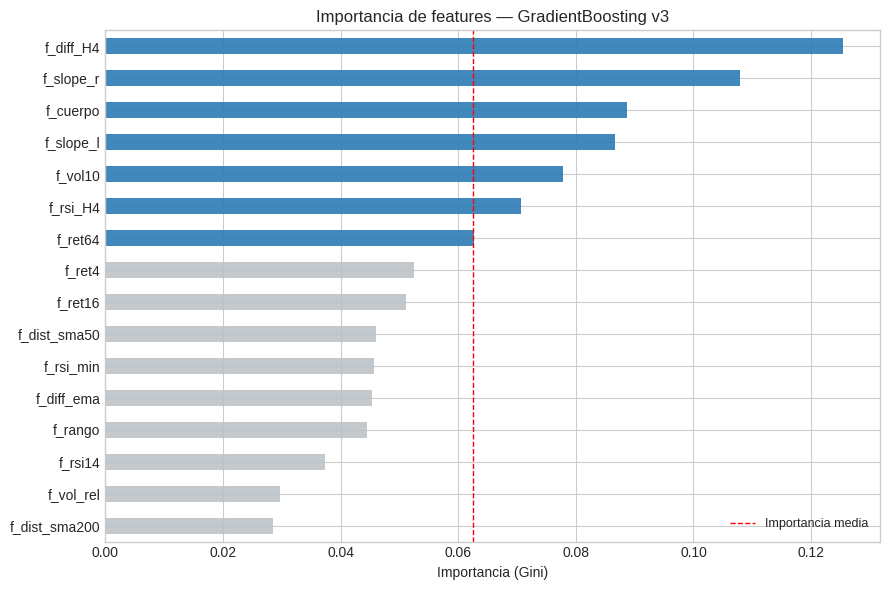


Top 5 features:
  f_diff_H4           : 0.1255
  f_slope_r           : 0.1079
  f_cuerpo            : 0.0886
  f_slope_l           : 0.0866
  f_vol10             : 0.0779


In [9]:
modelo = GradientBoostingClassifier(
    n_estimators     = 500,
    learning_rate    = 0.02,
    max_depth        = 3,
    min_samples_leaf = 15,
    subsample        = 0.8,
    max_features     = 'sqrt',
    validation_fraction = 0.15,
    n_iter_no_change = 30,     # early stopping
    tol              = 1e-4,
    random_state     = 42,
)

print('Entrenando GradientBoosting con early stopping...')
modelo.fit(X_train_sc, y_train)
print(f'Completado en {modelo.n_estimators_} iteraciones (early stop).')

# Importancia de features
imp = pd.Series(modelo.feature_importances_, index=FEATURES).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 6))
colores_imp = ['#2c7bb6' if v >= imp.mean() else '#bdc3c7' for v in imp.values]
imp.plot(kind='barh', ax=ax, color=colores_imp, alpha=0.9)
ax.axvline(imp.mean(), color='red', ls='--', lw=1, label='Importancia media')
ax.set_title('Importancia de features — GradientBoosting v3')
ax.set_xlabel('Importancia (Gini)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print('\nTop 5 features:')
for f, v in imp.sort_values(ascending=False).head(5).items():
    print(f'  {f:<20}: {v:.4f}')

## Celda 11 — Evaluación del modelo


=== ENTRENAMIENTO (n=545) ===
               precision    recall  f1-score   support

 SL (perdida)       0.67      1.00      0.80       363
TP (ganancia)       0.00      0.00      0.00       182

     accuracy                           0.67       545
    macro avg       0.33      0.50      0.40       545
 weighted avg       0.44      0.67      0.53       545

AUC-ROC: 0.7669

=== VALIDACIÓN (n=117) ===
               precision    recall  f1-score   support

 SL (perdida)       0.67      1.00      0.80        78
TP (ganancia)       0.00      0.00      0.00        39

     accuracy                           0.67       117
    macro avg       0.33      0.50      0.40       117
 weighted avg       0.44      0.67      0.53       117

AUC-ROC: 0.5082

=== TEST (n=117) ===
               precision    recall  f1-score   support

 SL (perdida)       0.65      1.00      0.79        76
TP (ganancia)       0.00      0.00      0.00        41

     accuracy                           0.65       117

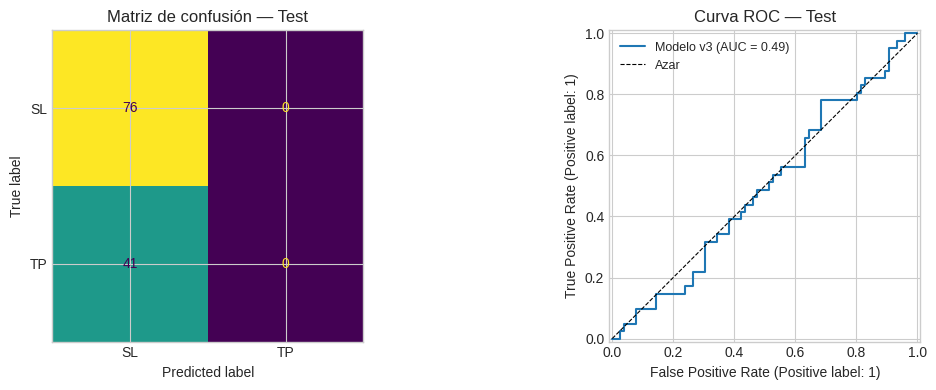

In [10]:
def evaluar(nombre, X_sc, y_real):
    y_pred = modelo.predict(X_sc)
    y_prob = modelo.predict_proba(X_sc)[:, 1]
    auc    = roc_auc_score(y_real, y_prob)
    print(f'\n=== {nombre} (n={len(y_real)}) ===')
    print(classification_report(y_real, y_pred,
                                  target_names=['SL (perdida)', 'TP (ganancia)']))
    print(f'AUC-ROC: {auc:.4f}')
    return y_pred, y_prob, auc

_, _,       auc_tr  = evaluar('ENTRENAMIENTO', X_train_sc, y_train)
_, _,       auc_val = evaluar('VALIDACIÓN',    X_val_sc,   y_val)
yp, ypr,   auc_te  = evaluar('TEST',           X_test_sc,  y_test)

print()
print('=' * 50)
print('RESUMEN')
print(f'  AUC Train     : {auc_tr:.4f}')
print(f'  AUC Validación: {auc_val:.4f}')
print(f'  AUC Test      : {auc_te:.4f}')
gap = auc_tr - auc_te
print(f'  Gap train-test: {gap:.4f} → {"Overfitting" if gap > 0.05 else "OK"}')
print('=' * 50)
print()
print('NOTA: Con señales ya filtradas (solo las mejores cruces),')
print('el objetivo es AUC > 0.52. El modelo completa el filtrado.')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ConfusionMatrixDisplay(
    confusion_matrix(y_test, yp),
    display_labels=['SL', 'TP']
).plot(ax=axes[0], colorbar=False)
axes[0].set_title('Matriz de confusión — Test')

RocCurveDisplay.from_predictions(y_test, ypr, ax=axes[1], name='Modelo v3')
axes[1].plot([0,1],[0,1],'k--', lw=0.8, label='Azar')
axes[1].set_title('Curva ROC — Test')
axes[1].legend(fontsize=9)
plt.tight_layout()
plt.show()

## Celda 12 — Calibración del umbral

Encuentra el umbral óptimo analizando la relación entre
win rate, número de señales y valor esperado por operación.

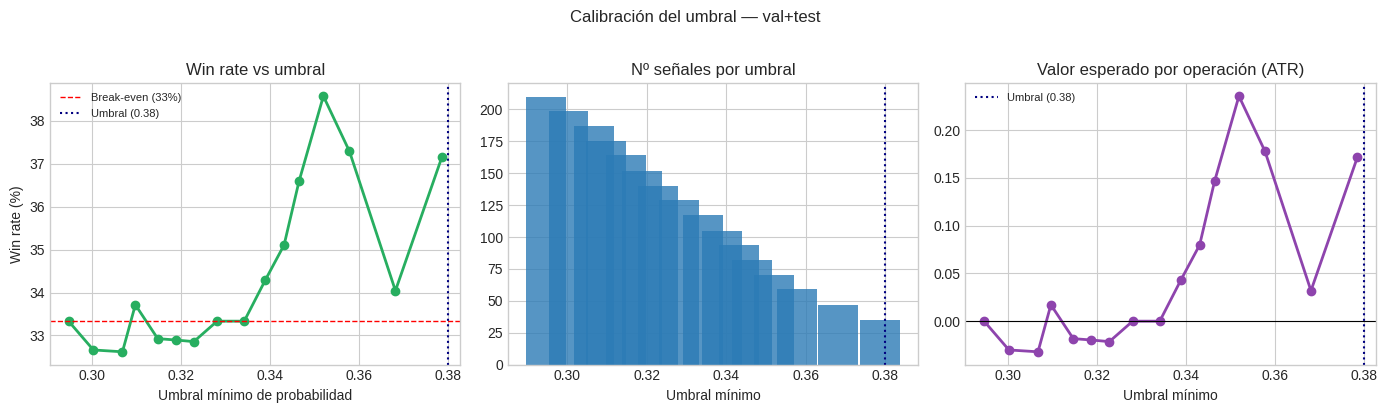


  Umbral  Señales   Win Rate   EV (ATR)   Rentable
----------------------------------------------------
   0.295      210      33.3%      0.000         NO
   0.300      199      32.7%     -0.030         NO
   0.307      187      32.6%     -0.032         NO
   0.310      175      33.7%      0.017         SÍ
   0.315      164      32.9%     -0.018         NO
   0.319      152      32.9%     -0.020         NO
   0.323      140      32.9%     -0.021         NO
   0.328      129      33.3%      0.000         NO
   0.334      117      33.3%      0.000         NO
   0.339      105      34.3%      0.043         SÍ
   0.343       94      35.1%      0.080         SÍ
   0.346       82      36.6%      0.146         SÍ
   0.352       70      38.6%      0.236         SÍ
   0.358       59      37.3%      0.178         SÍ
   0.368       47      34.0%      0.032         SÍ
   0.379       35      37.1%      0.171         SÍ ← actual

Umbral óptimo sugerido: 0.352
Ajusta UMBRAL_OPERAR en la Celda 4 si q

In [11]:
# Usar val+test para calibrar el umbral
X_cal   = np.vstack([X_val_sc, X_test_sc])
y_cal   = np.concatenate([y_val, y_test])
pr_cal  = modelo.predict_proba(X_cal)[:, 1]

umbrales  = np.percentile(pr_cal, np.arange(10, 90, 5))
resultados = []

for u in umbrales:
    mask = pr_cal >= u
    n    = mask.sum()
    if n < 5: continue
    wr   = y_cal[mask].mean()
    ev   = wr * TP_ATR - (1 - wr) * SL_ATR
    resultados.append({'umbral': u, 'n': n, 'wr': wr, 'ev': ev})

res_df = pd.DataFrame(resultados)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

be = 1 / (1 + TP_ATR / SL_ATR)
axes[0].plot(res_df['umbral'], res_df['wr']*100, 'o-', color='#27ae60', lw=2)
axes[0].axhline(be*100, color='red', ls='--', lw=1, label=f'Break-even ({be*100:.0f}%)')
axes[0].axvline(UMBRAL_OPERAR, color='navy', ls=':', lw=1.5, label=f'Umbral ({UMBRAL_OPERAR})')
axes[0].set_title('Win rate vs umbral')
axes[0].set_xlabel('Umbral mínimo de probabilidad')
axes[0].set_ylabel('Win rate (%)')
axes[0].legend(fontsize=8)

axes[1].bar(res_df['umbral'], res_df['n'], width=0.01, color='#2c7bb6', alpha=0.8)
axes[1].axvline(UMBRAL_OPERAR, color='navy', ls=':', lw=1.5)
axes[1].set_title('Nº señales por umbral')
axes[1].set_xlabel('Umbral mínimo')

axes[2].plot(res_df['umbral'], res_df['ev'], 'o-', color='#8e44ad', lw=2)
axes[2].axhline(0, color='black', lw=0.8)
axes[2].axvline(UMBRAL_OPERAR, color='navy', ls=':', lw=1.5, label=f'Umbral ({UMBRAL_OPERAR})')
axes[2].set_title('Valor esperado por operación (ATR)')
axes[2].set_xlabel('Umbral mínimo')
axes[2].legend(fontsize=8)

plt.suptitle('Calibración del umbral — val+test', y=1.02)
plt.tight_layout()
plt.show()

print(f'\n{"Umbral":>8} {"Señales":>8} {"Win Rate":>10} {"EV (ATR)":>10} {"Rentable":>10}')
print('-' * 52)
for _, r in res_df.iterrows():
    marca = ' ← actual' if abs(r['umbral'] - UMBRAL_OPERAR) < 0.01 else ''
    rent  = 'SÍ' if r['ev'] > 0 else 'NO'
    print(f"{r['umbral']:>8.3f} {r['n']:>8.0f} {r['wr']*100:>9.1f}% {r['ev']:>10.3f} {rent:>10}{marca}")

# Umbral óptimo = mayor EV con al menos 10 señales
validos = res_df[res_df['n'] >= 10]
if not validos.empty:
    optimo = validos.loc[validos['ev'].idxmax(), 'umbral']
    print(f'\nUmbral óptimo sugerido: {optimo:.3f}')
    print(f'Ajusta UMBRAL_OPERAR en la Celda 4 si quieres usarlo.')

## Celda 13 — Backtest completo con VectorBT

Compara tres escenarios:
1. **Buy & Hold** (referencia)
2. **Regla base** (cruce + filtros, sin modelo)
3. **Estrategia v3** (cruce + filtros + modelo ML)

In [15]:
# Celda temporal — inspeccionar claves reales de VectorBT
# Ejecuta esto UNA VEZ y luego borra esta celda

entrada_prueba = pd.Series(False, index=precios_test.index)
idx_prueba = idx_test[0]
if idx_prueba in entrada_prueba.index:
    entrada_prueba[idx_prueba] = True

pf_prueba = vbt.Portfolio.from_signals(
    precios_test,
    entries=entrada_prueba,
    exits=entrada_prueba.shift(1, fill_value=False),
    init_cash=10_000, fees=0.0001, slippage=0.0001
)

print("Claves disponibles en pf.stats():")
for k in pf_prueba.stats().index.tolist():
    print(f"  '{k}'")

Claves disponibles en pf.stats():
  'Start'
  'End'
  'Period'
  'Start Value'
  'End Value'
  'Total Return [%]'
  'Benchmark Return [%]'
  'Max Gross Exposure [%]'
  'Total Fees Paid'
  'Max Drawdown [%]'
  'Max Drawdown Duration'
  'Total Trades'
  'Total Closed Trades'
  'Total Open Trades'
  'Open Trade PnL'
  'Win Rate [%]'
  'Best Trade [%]'
  'Worst Trade [%]'
  'Avg Winning Trade [%]'
  'Avg Losing Trade [%]'
  'Avg Winning Trade Duration'
  'Avg Losing Trade Duration'
  'Profit Factor'
  'Expectancy'


Señales en test:
  Regla base (sin modelo) : 117
  Con modelo (umbral 0.38): 17
  Filtrado modelo         : 85% de señales rechazadas

=== COMPARATIVA DE RESULTADOS ===
Período: 2025-12-23 → 2026-07-03
Capital: $10,000

Métrica                             B&H       Base   + Modelo
--------------------------------------------------------------
Retorno total (%)                  9.05      -5.88      -0.23
Drawdown máximo (%)                   —       5.96       0.43
Tasa de aciertos (%)                  —      20.51      29.41
Total operaciones                     —        117         17
Factor de beneficio                   —       0.22       0.64
Expectancy                            —      -5.02      -1.34
Mejor trade (%)                       —       0.32       0.32
Peor trade (%)                        —      -0.98      -0.10


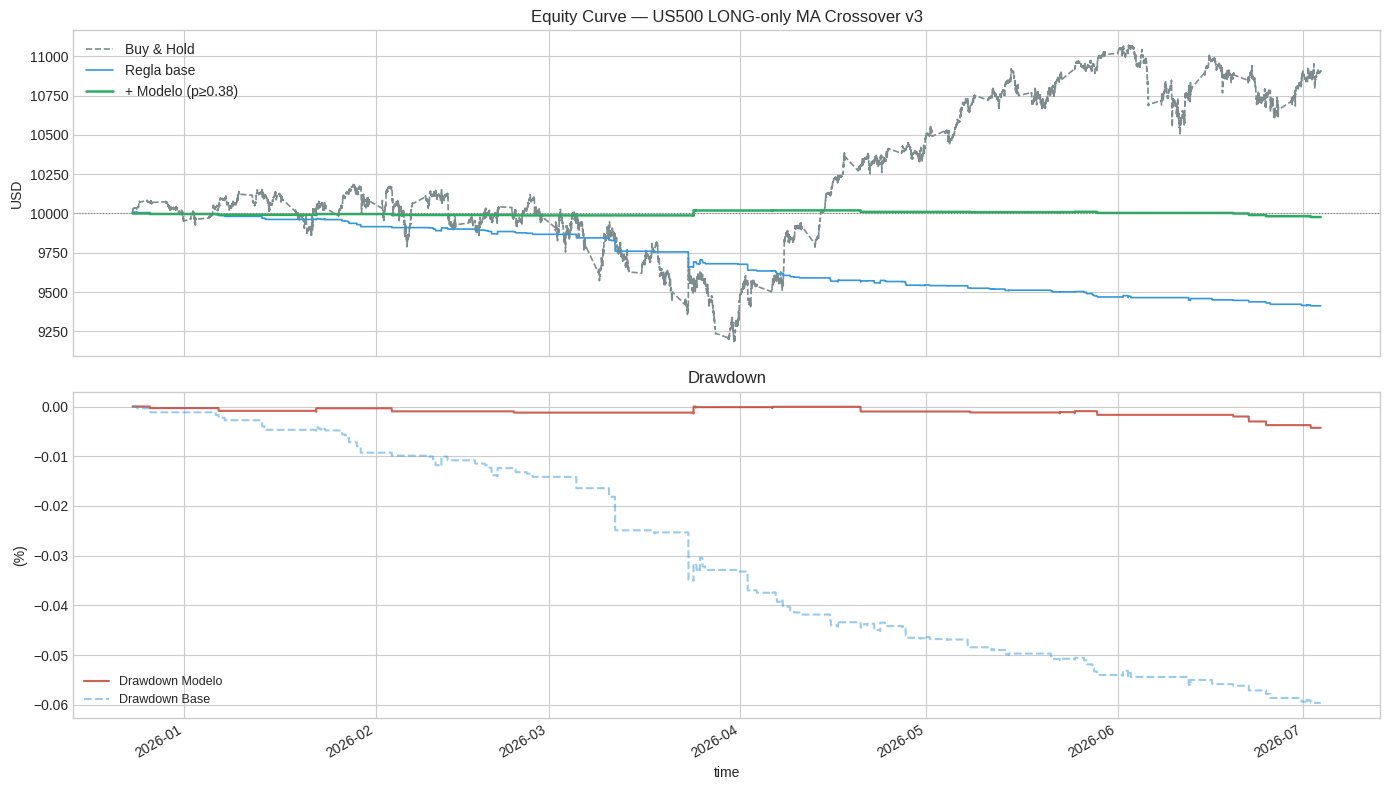


NOTA: Valida siempre en cuenta demo antes de operar con dinero real.


In [16]:
import vectorbt as vbt

# Precio completo del período de test
fecha_test_ini  = ds.index[c2]
precios_test    = df.loc[fecha_test_ini:, 'close']
probs_test      = modelo.predict_proba(X_test_sc)[:, 1]
idx_test        = ds.index[c2:]

CAPITAL  = 10_000
COMISION = 0.0001
SLIP     = 0.0001

# ── Escenario 1: Buy & Hold ───────────────────────────────────
ret_bah = (precios_test.iloc[-1] / precios_test.iloc[0] - 1) * 100

# ── Escenario 2: Regla base (filtros, sin modelo) ─────────────
entradas_base = pd.Series(False, index=precios_test.index)
for idx in idx_test:
    if idx in entradas_base.index:
        entradas_base[idx] = True

# ── Escenario 3: Con modelo ML (umbral) ───────────────────────
entradas_ml = pd.Series(False, index=precios_test.index)
for idx, prob in zip(idx_test, probs_test):
    if prob >= UMBRAL_OPERAR and idx in entradas_ml.index:
        entradas_ml[idx] = True

n_base = entradas_base.sum()
n_ml   = entradas_ml.sum()
print(f'Señales en test:')
print(f'  Regla base (sin modelo) : {n_base}')
print(f'  Con modelo (umbral {UMBRAL_OPERAR}): {n_ml}')
print(f'  Filtrado modelo         : {(1-n_ml/n_base)*100:.0f}% de señales rechazadas' if n_base > 0 else '  Sin señales base')

def backtest_long(entradas, precio, capital, fees, slip):
    if entradas.sum() == 0:
        return None
    salidas = entradas.shift(1, fill_value=False)
    return vbt.Portfolio.from_signals(
        precio, entries=entradas, exits=salidas,
        init_cash=capital, fees=fees, slippage=slip
    )

pf_base = backtest_long(entradas_base, precios_test, CAPITAL, COMISION, SLIP)
pf_ml   = backtest_long(entradas_ml,   precios_test, CAPITAL, COMISION, SLIP)

# ── Tabla comparativa ─────────────────────────────────────────
stats_base = pf_base.stats() if pf_base else pd.Series(dtype=float)
stats_ml   = pf_ml.stats()   if pf_ml   else pd.Series(dtype=float)

metricas = [
    ('Retorno total (%)',    'Total Return [%]'),
    ('Drawdown máximo (%)', 'Max Drawdown [%]'),
    ('Tasa de aciertos (%)', 'Win Rate [%]'),
    ('Total operaciones',   'Total Trades'),
    ('Factor de beneficio', 'Profit Factor'),
    ('Expectancy',          'Expectancy'),
    ('Mejor trade (%)',     'Best Trade [%]'),
    ('Peor trade (%)',      'Worst Trade [%]'),
]

print(f'\n=== COMPARATIVA DE RESULTADOS ===')
print(f'Período: {fecha_test_ini.date()} → {df.index[-1].date()}')
print(f'Capital: ${CAPITAL:,}')
print()
print(f'{"Métrica":<28} {"B&H":>10} {"Base":>10} {"+ Modelo":>10}')
print('-' * 62)

for label, key in metricas:
    v_base = stats_base[key] if key in stats_base.index else float('nan')
    v_ml   = stats_ml[key]   if key in stats_ml.index   else float('nan')

    if label == 'Total operaciones':
        b   = f'{v_base:.0f}' if not np.isnan(v_base) else '—'
        m   = f'{v_ml:.0f}'   if not np.isnan(v_ml)   else '—'
        bah = '—'
    elif label == 'Retorno total (%)':
        b   = f'{v_base:.2f}' if not np.isnan(v_base) else '—'
        m   = f'{v_ml:.2f}'   if not np.isnan(v_ml)   else '—'
        bah = f'{ret_bah:.2f}'
    else:
        b   = f'{v_base:.2f}' if not np.isnan(v_base) else '—'
        m   = f'{v_ml:.2f}'   if not np.isnan(v_ml)   else '—'
        bah = '—'

    print(f'{label:<28} {bah:>10} {b:>10} {m:>10}')

# ── Gráfico comparativo ───────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

bah_equity = CAPITAL * (precios_test / precios_test.iloc[0])
bah_equity.rename('Buy & Hold').plot(
    ax=axes[0], color='#7f8c8d', lw=1.2, ls='--')
if pf_base:
    pf_base.value().rename('Regla base').plot(
        ax=axes[0], color='#3498db', lw=1.2)
if pf_ml:
    pf_ml.value().rename(f'+ Modelo (p≥{UMBRAL_OPERAR})').plot(
        ax=axes[0], color='#27ae60', lw=1.8)
axes[0].axhline(CAPITAL, color='gray', ls=':', lw=0.8)
axes[0].set_title('Equity Curve — US500 LONG-only MA Crossover v3')
axes[0].set_ylabel('USD')
axes[0].legend(fontsize=10)

if pf_ml:
    pf_ml.drawdown().rename('Drawdown Modelo').plot(
        ax=axes[1], color='#c0392b', alpha=0.8)
if pf_base:
    pf_base.drawdown().rename('Drawdown Base').plot(
        ax=axes[1], color='#3498db', alpha=0.5, ls='--')
axes[1].set_title('Drawdown')
axes[1].set_ylabel('(%)')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

print()
print('NOTA: Valida siempre en cuenta demo antes de operar con dinero real.')

## Celda 14 — Exportación a ONNX

In [17]:
NOMBRE_MODELO = 'modelo_us500_v3.onnx'

onnx_modelo = convert_sklearn(
    modelo,
    initial_types = [('float_input', FloatTensorType([None, len(FEATURES)]))],
    target_opset  = 12,
    options       = {id(modelo): {'zipmap': False}}
)

with open(NOMBRE_MODELO, 'wb') as f:
    f.write(onnx_modelo.SerializeToString())

# Validar
sesion    = ort.InferenceSession(NOMBRE_MODELO)
nombre_in = sesion.get_inputs()[0].name
muestra   = X_test_sc[:5].astype(np.float32)
pred_onnx = sesion.run(None, {nombre_in: muestra})
pred_sk   = modelo.predict_proba(muestra)
diff      = np.abs(pred_sk - pred_onnx[1]).max()

print(f'Modelo exportado : {NOMBRE_MODELO}')
print(f'Tamaño           : {len(onnx_modelo.SerializeToString())/1024:.1f} KB')
print(f'Diferencia max   : {diff:.2e}')
print('VALIDACION OK' if diff < 1e-4 else 'ADVERTENCIA — revisar')

Modelo exportado : modelo_us500_v3.onnx
Tamaño           : 14.2 KB
Diferencia max   : 5.20e-08
VALIDACION OK


## Celda 15 — Parámetros para config.py y descarga

In [18]:
print('=' * 68)
print('BLOQUE PARA config.py DEL AGENTE')
print('=' * 68)
print()
print(f'    # Instrumento y timeframe')
print(f'    symbol             = "US500"')
print(f'    timeframe          = "M15"')
print(f'    n_bars             = 300')
print()
print(f'    # Modelo')
print(f'    modelo_path        = "{NOMBRE_MODELO}"')
print(f'    umbral_buy         = {UMBRAL_OPERAR}   # SOLO señales LONG')
print(f'    umbral_sell        = 99.0               # NUNCA corto en US500')
print()
print(f'    # SL/TP')
print(f'    sl_atr_mult        = {SL_ATR}')
print(f'    tp_atr_mult        = {TP_ATR}')
print()
print(f'    # Filtros de señal (deben replicarse en features.py)')
print(f'    ema_rapida         = {EMA_RAPIDA}    # períodos M15')
print(f'    ema_lenta          = {EMA_LENTA}    # períodos M15')
print(f'    sma_tendencia      = {SMA_TENDENCIA}   # períodos M15')
print(f'    rsi_pullback       = {RSI_PULLBACK}    # nivel de pullback')
print(f'    lookback_rsi       = {LOOKBACK_RSI}     # velas de lookback')
print()
print(f'    # Scaler (generado en esta sesión de entrenamiento)')
print(f'    scaler_mean        = {scaler.mean_.tolist()}')
print(f'    scaler_scale       = {scaler.scale_.tolist()}')
print()
print(f'    # Features en este orden exacto:')
for i, f in enumerate(FEATURES):
    print(f'    #   [{i:02d}] {f}')
print('=' * 68)

# Descargar
try:
    from google.colab import files
    files.download(NOMBRE_MODELO)
    print(f'\nDescarga iniciada: {NOMBRE_MODELO}')
except ImportError:
    import os
    print(f'\nArchivo: {os.path.abspath(NOMBRE_MODELO)}')

BLOQUE PARA config.py DEL AGENTE

    # Instrumento y timeframe
    symbol             = "US500"
    timeframe          = "M15"
    n_bars             = 300

    # Modelo
    modelo_path        = "modelo_us500_v3.onnx"
    umbral_buy         = 0.38   # SOLO señales LONG
    umbral_sell        = 99.0               # NUNCA corto en US500

    # SL/TP
    sl_atr_mult        = 1.5
    tp_atr_mult        = 3.0

    # Filtros de señal (deben replicarse en features.py)
    ema_rapida         = 9    # períodos M15
    ema_lenta          = 21    # períodos M15
    sma_tendencia      = 200   # períodos M15
    rsi_pullback       = 45    # nivel de pullback
    lookback_rsi       = 8     # velas de lookback

    # Scaler (generado en esta sesión de entrenamiento)
    scaler_mean        = [0.08608516483383954, 0.4974131816041169, 0.18318961823418942, 0.9768082826555313, 4.942722278710352, 0.17369201552344982, -0.23083457229060864, 0.08841689526212376, 3.6615290161957024, 0.7558736676615108, 1.3600

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Descarga iniciada: modelo_us500_v3.onnx
